In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sklearn

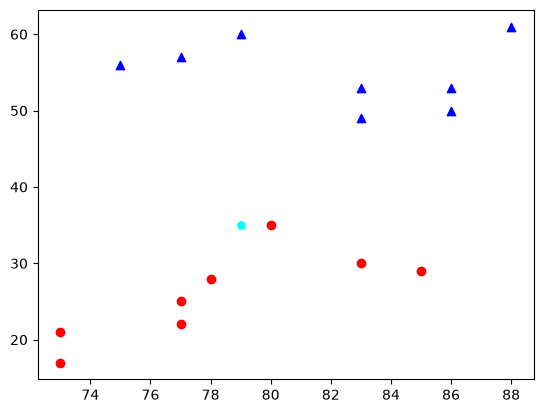

In [2]:
dach_length = [77, 78, 85, 83 ,73, 77, 73, 80]
dach_height = [25, 28, 29, 30, 21, 22, 17, 35]
samo_length = [75, 77, 86, 86, 79, 83, 83, 88]
samo_height = [56, 57, 50, 53, 60, 53, 49, 61]

plt.scatter(dach_length, dach_height, color='red', label='Dachshund')
plt.scatter(samo_length, samo_height, color='blue', marker='^', label='Samoyed')
plt.scatter([79], [35], color='cyan', marker='p')

plt.show()

In [3]:
import numpy as np

In [4]:
dach_data = np.column_stack((dach_length, dach_height))
print(dach_data)
print(dach_data.shape)

[[77 25]
 [78 28]
 [85 29]
 [83 30]
 [73 21]
 [77 22]
 [73 17]
 [80 35]]
(8, 2)


In [5]:
dach_target = [0] * 8
print(dach_target)

[0, 0, 0, 0, 0, 0, 0, 0]


In [6]:
samo_data = np.column_stack((samo_length, samo_height))
print(samo_data)
print(samo_data.shape)

[[75 56]
 [77 57]
 [86 50]
 [86 53]
 [79 60]
 [83 53]
 [83 49]
 [88 61]]
(8, 2)


In [7]:
samo_target = [1] * 8
print(samo_target)

[1, 1, 1, 1, 1, 1, 1, 1]


In [8]:
dogs = np.concatenate((dach_data, samo_data))
print(dogs.shape)

(16, 2)


In [9]:
labels = np.concatenate((dach_target, samo_target))
print(labels)
print(labels.shape)

[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1]
(16,)


In [10]:
from sklearn.neighbors import KNeighborsClassifier

In [11]:
from sklearn import config_context

with config_context(display='text'):
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(dogs, labels)
    print(knn)

KNeighborsClassifier(n_neighbors=3)

In [12]:
unknown_dog = [[79, 35]]
print(knn.predict(unknown_dog))

[0]

In [13]:
dach_length = [77, 78, 85, 83 ,73, 77, 73, 80]
dach_length_mean = sum(dach_length) / len(dach_length)
print(dach_length_mean)

78.25


In [14]:
new_dach_length = np.random.normal(loc=78.25, scale=5.0, size=(200,))
print(new_dach_length.shape)

(200,)


In [15]:
samo_length = [75, 77, 86, 86, 79, 83, 83, 88]
samo_length_mean = sum(samo_length) / len(samo_length)
print(samo_length_mean)

82.125


In [16]:
new_samo_length = np.random.normal(loc=82.125, scale=5.0, size=(200,))
print(new_samo_length.shape)

(200,)


In [17]:
dach_height = [25, 28, 29, 30, 21, 22, 17, 35]
dach_height_mean = sum(dach_height) / len(dach_height)
print(dach_height_mean)

25.875


In [18]:
new_dach_height = np.random.normal(loc=25.875, scale=5.0, size=(200,))
print(new_dach_height.shape)

(200,)


In [19]:
samo_height = [56, 57, 50, 53, 60, 53, 49, 61]
samo_height_mean = sum(samo_height) / len(samo_height)
print(samo_height_mean)

54.875


In [20]:
new_samo_height = np.random.normal(loc=54.875, scale=5.0, size=(200,))
print(new_samo_height.shape)

(200,)


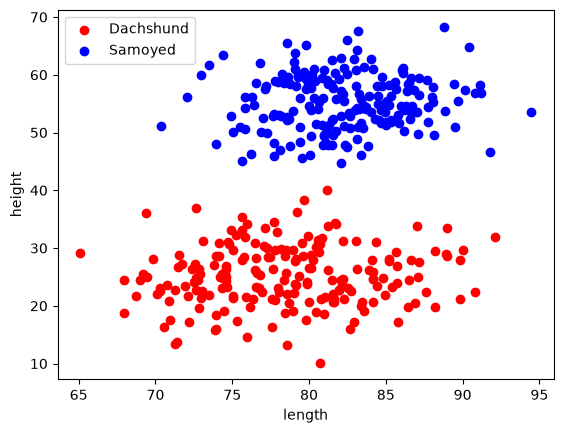

In [21]:
plt.scatter(new_dach_length, new_dach_height, color='red', label='Dachshund')
plt.scatter(new_samo_length, new_samo_height, color='blue', label='Samoyed')
plt.xlabel('length')
plt.ylabel('height')
plt.legend(loc='upper left')
plt.show()

In [22]:
new_dach_data = np.column_stack((new_dach_length, new_dach_height))
print(new_dach_data.shape)

(200, 2)


In [23]:
new_samo_data = np.column_stack((new_samo_length, new_samo_height))
print(new_samo_data.shape)

(200, 2)


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [25]:
new_dach_target = np.zeros(200)
print(new_dach_target.shape)

(200,)


In [26]:
new_samo_target = np.ones(200)
print(new_samo_target.shape)

(200,)


In [27]:
all_dogs_data = np.concatenate((new_dach_data, new_samo_data))
all_dogs_target = np.concatenate((new_dach_target, new_samo_target))

print(all_dogs_data[:5])
print(all_dogs_target[:5])
print(all_dogs_data.shape)
print(all_dogs_target.shape)

[[77.24367723 30.00118111]
 [76.76109419 23.05628622]
 [71.30036999 13.33048486]
 [78.4865176  29.6845458 ]
 [81.95104569 22.74729096]]
[0. 0. 0. 0. 0.]
(400, 2)
(400,)


In [28]:
all_data, new_data, all_target, new_target = train_test_split(
    all_dogs_data,
    all_dogs_target,
    test_size=0.2,
    random_state=42
)

X_train, X_test, y_train, y_test = all_data, new_data, all_target, new_target

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(320, 2)
(80, 2)
(320,)
(80,)


In [29]:
knn_train = KNeighborsClassifier(3)
knn_train.fit(X_train, y_train)

print(knn_train)

KNeighborsClassifier(n_neighbors=3)


In [30]:
y_predict = knn_train.predict(X_test)

print(y_predict[:10])
print(y_test[:10])
print(y_predict.shape)

[1. 1. 0. 1. 0. 0. 1. 0. 1. 0.]
[1. 1. 0. 1. 0. 0. 1. 0. 1. 0.]
(80,)


In [31]:
accuracy = accuracy_score(y_test, y_predict)
print(f"정확도: {accuracy:.4f}")


정확도: 1.0000


In [32]:
print(classification_report(y_test, y_predict, target_names=['Dachshund', 'Samoyed']))

              precision    recall  f1-score   support

   Dachshund       1.00      1.00      1.00        44
     Samoyed       1.00      1.00      1.00        36

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [33]:
train_score = knn_train.score(X_train, y_train)
test_score = knn_train.score(X_test, y_test)


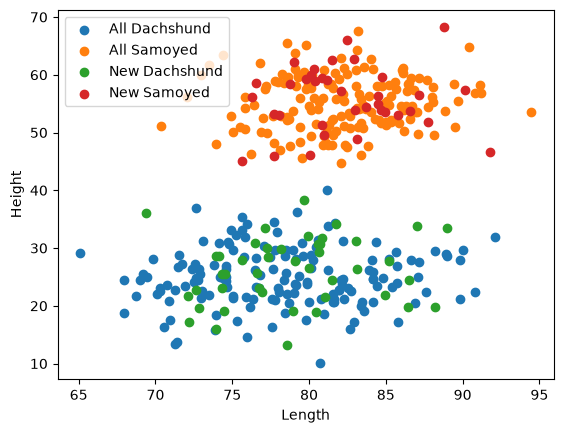

In [34]:
plt.scatter(all_data[all_target == 0, 0], all_data[all_target == 0, 1], label='All Dachshund')
plt.scatter(all_data[all_target == 1, 0], all_data[all_target == 1, 1], label='All Samoyed')
plt.scatter(new_data[new_target == 0, 0], new_data[new_target == 0, 1], label='New Dachshund')
plt.scatter(new_data[new_target == 1, 0], new_data[new_target == 1, 1], label='New Samoyed')

plt.xlabel('Length')
plt.ylabel('Height')
plt.legend(loc='upper left')
plt.show()
